# Conceitos Fundamentais em Conjuntos Fuzzy: Cut, Crisp e Convexidade

Este notebook apresenta explicações e exemplos sobre os conceitos de **cut (α-cut)**, **crisp** e **convexidade** em conjuntos fuzzy.

## 1. Cut (α-cut)

O **α-cut** (ou corte α) de um conjunto fuzzy $A$ é o subconjunto dos elementos do universo cujos graus de pertinência são maiores ou iguais a um valor $\alpha \in [0,1]$.

**Definição formal:**
$$
A_\alpha = \{ x \in X \mid \mu_A(x) \geq \alpha \}
$$

O α-cut transforma um conjunto fuzzy em um conjunto clássico (crisp) para um dado nível α.

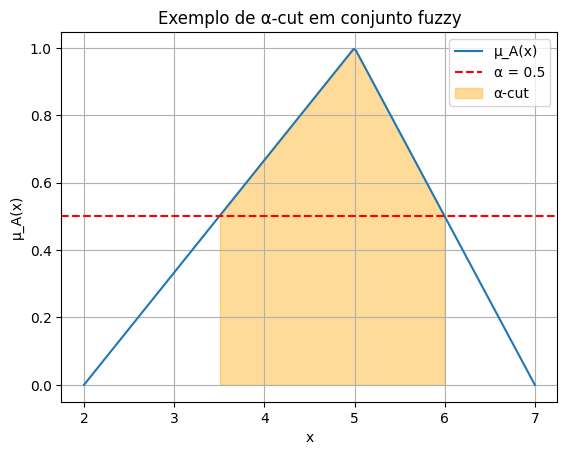

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Função de pertinência triangular
def mu_A(x):
    return np.maximum(np.minimum((x-2)/3, (7-x)/2), 0)

x = np.linspace(2, 7, 200)
y = mu_A(x)

alpha = 0.5
cut_indices = y >= alpha

plt.plot(x, y, label='μ_A(x)')
plt.axhline(alpha, color='red', linestyle='--', label=f'α = {alpha}')
plt.fill_between(x, 0, y, where=cut_indices, color='orange', alpha=0.4, label='α-cut')
plt.title('Exemplo de α-cut em conjunto fuzzy')
plt.xlabel('x')
plt.ylabel('μ_A(x)')
plt.legend()
plt.grid(True)
plt.show()

## 2. Crisp

Um conjunto **crisp** (ou clássico) é aquele em que cada elemento pertence ou não pertence ao conjunto, ou seja, o grau de pertinência é sempre 0 ou 1.

- **Conjunto crisp:** $\mu_A(x) \in \{0, 1\}$
- **Conjunto fuzzy:** $\mu_A(x) \in [0, 1]$

O α-cut de um conjunto fuzzy para um dado α resulta em um conjunto crisp.

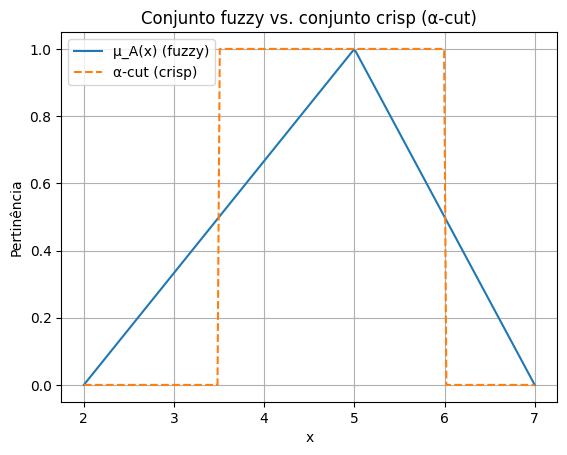

In [5]:
# Exemplo: comparação entre conjunto fuzzy e crisp resultante do α-cut
plt.plot(x, y, label='μ_A(x) (fuzzy)')
plt.plot(x, (y >= alpha).astype(float), label='α-cut (crisp)', linestyle='--')
plt.title('Conjunto fuzzy vs. conjunto crisp (α-cut)')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

## 3. Convexidade em Conjuntos Fuzzy

Um conjunto fuzzy $A$ é **convexo** se, para quaisquer $x_1, x_2 \in X$ e qualquer $\lambda \in [0,1]$, vale:
$$
\mu_A(\lambda x_1 + (1-\lambda)x_2) \geq \min(\mu_A(x_1), \mu_A(x_2))
$$

Ou seja, o grau de pertinência de qualquer ponto intermediário entre $x_1$ e $x_2$ não é menor que o menor grau de pertinência desses pontos.

**Exemplo:**  
Funções de pertinência triangulares e trapezoidais são convexas.

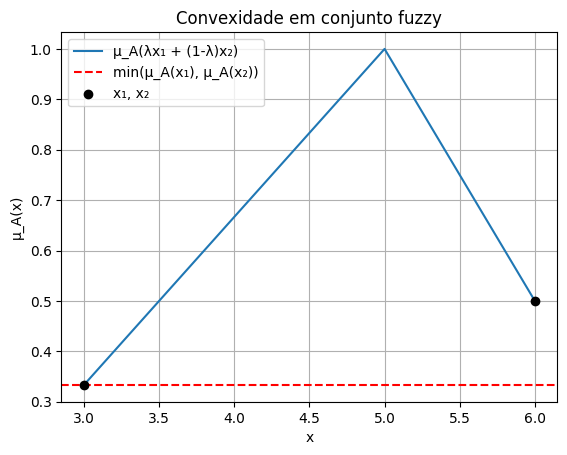

In [6]:
# Exemplo visual de convexidade
x1, x2 = 3, 6
lambdas = np.linspace(0, 1, 100)
interpolados = lambdas * x1 + (1 - lambdas) * x2
mu_x1 = mu_A(x1)
mu_x2 = mu_A(x2)
mu_interpolados = mu_A(interpolados)
min_mu = min(mu_x1, mu_x2)

plt.plot(interpolados, mu_interpolados, label='μ_A(λx₁ + (1-λ)x₂)')
plt.axhline(min_mu, color='red', linestyle='--', label='min(μ_A(x₁), μ_A(x₂))')
plt.scatter([x1, x2], [mu_x1, mu_x2], color='black', zorder=5, label='x₁, x₂')
plt.title('Convexidade em conjunto fuzzy')
plt.xlabel('x')
plt.ylabel('μ_A(x)')
plt.legend()
plt.grid(True)
plt.show()

**Resumo:**

- **α-cut:** Subconjunto crisp de um fuzzy para um nível α.
- **Crisp:** Conjunto clássico, pertinência 0 ou 1.
- **Convexidade:** Não há "vales" entre pontos de pertinência, importante para propriedades matemáticas dos conjuntos fuzzy.

## 4. Domínio de um Conjunto Fuzzy

O **domínio** de um conjunto fuzzy $A$ é o universo de discurso $X$ sobre o qual a função de pertinência $\mu_A(x)$ está definida.

**Exemplo:**  
Se $X = [0, 10]$, então o domínio de $A$ é $[0, 10]$.

## 5. Cut Forte (Strong α-cut)

O **cut forte** (ou strong α-cut) de um conjunto fuzzy $A$ para $\alpha \in (0, 1]$ é o subconjunto dos elementos cujo grau de pertinência é estritamente maior que $\alpha$:

$$
A_{(\alpha)} = \{ x \in X \mid \mu_A(x) > \alpha \}
$$

**Exemplo:**  
Se $\mu_A(4) = 0.6$ e $\alpha = 0.5$, então $4 \in A_{(0.5)}$.

## 6. Altura de um Conjunto Fuzzy

A **altura** de um conjunto fuzzy $A$ é o maior valor de pertinência de seus elementos:

$$
h(A) = \sup_{x \in X} \mu_A(x)
$$

- Se $h(A) = 1$, $A$ é chamado de **normalizado**.

**Exemplo:**  
Se $\max \mu_A(x) = 0.8$, então a altura de $A$ é $0.8$.

In [7]:
# Exemplo de altura
altura = np.max(y)
print(f"Altura do conjunto fuzzy A: {altura:.2f}")

Altura do conjunto fuzzy A: 1.00


## 7. Suporte de um Conjunto Fuzzy

O **suporte** de um conjunto fuzzy $A$ é o conjunto dos elementos do domínio para os quais $\mu_A(x) > 0$:

$$
\text{supp}(A) = \{ x \in X \mid \mu_A(x) > 0 \}
$$

**Exemplo:**  
Para uma função triangular entre $a$ e $c$, o suporte é o intervalo $(a, c)$.

In [8]:
# Exemplo de suporte
suporte = x[y > 0]
print(f"Suporte de A: de {suporte[0]:.2f} até {suporte[-1]:.2f}")

Suporte de A: de 2.03 até 6.97


## 8. Núcleo (Nucleus) de um Conjunto Fuzzy

O **núcleo** (ou núcleo) de um conjunto fuzzy $A$ é o conjunto dos elementos com pertinência máxima:

$$
\text{nuc}(A) = \{ x \in X \mid \mu_A(x) = h(A) \}
$$

**Exemplo:**  
Para uma função triangular com pico em $b$, o núcleo é $\{b\}$.

In [9]:
# Exemplo de núcleo
nucleo = x[np.isclose(y, altura)]
print(f"Núcleo de A: {nucleo}")

Núcleo de A: [4.98994975]


## 9. Inclusão e Subconjunto Fuzzy

Dizemos que $A$ é subconjunto de $B$ ($A \subseteq B$) se, para todo $x \in X$:

$$
\mu_A(x) \leq \mu_B(x)
$$

**Exemplo:**  
Se $\mu_A(x) = 0.4$ e $\mu_B(x) = 0.7$ para todo $x$, então $A \subseteq B$.

In [10]:
# Exemplo de inclusão
y_B = np.minimum(1, y + 0.3)  # B é sempre maior ou igual a A
inclusao = np.all(y <= y_B)
print(f"A é subconjunto de B? {inclusao}")

A é subconjunto de B? True


## 10. Cardinalidade de um Conjunto Fuzzy

A **cardinalidade** de um conjunto fuzzy $A$ é a soma dos graus de pertinência de todos os elementos do domínio (ou a integral, se contínuo):

$$
\text{card}(A) = \sum_{x \in X} \mu_A(x)
$$

**Exemplo:**  
Para $x = [2, 3, 4]$ e $\mu_A(x) = [0.2, 0.5, 1.0]$, então $\text{card}(A) = 0.2 + 0.5 + 1.0 = 1.7$.

In [11]:
# Exemplo de cardinalidade (discreto)
cardinalidade = np.sum(y)
print(f"Cardinalidade de A (aprox.): {cardinalidade:.2f}")

Cardinalidade de A (aprox.): 99.50


## 11. Convexidade em Conjuntos Fuzzy (Relembrando)

Um conjunto fuzzy $A$ é **convexo** se, para quaisquer $x_1, x_2 \in X$ e qualquer $\lambda \in [0,1]$:

$$
\mu_A(\lambda x_1 + (1-\lambda)x_2) \geq \min(\mu_A(x_1), \mu_A(x_2))
$$

**Exemplo:**  
Funções triangulares e trapezoidais são convexas.  
Funções com "vales" não são convexas.